# Mini Project

Solutions from:   

Name: **Manoj Billur Nagendra Prasad**   
Matriculation Number: 2886261

Name: **Steffi Stephen**  
Matriculation Number: 4109600

Objectives of this notebook:

This notebook explains the predictions of the trained Random Forest model using both global and local Explainable AI techniques. Feature importance, partial dependence, ICE plots, and SHAP are used to understand how the model makes predictions.

1. Load the trained machine learning model.
2. Explain the model using global explanation methods.
3. Analyze the influence of important features.
4. Explain individual feature effects.
5. Explain individual predictions using SHAP.

This notebook uses the following inputs:

| File | Description |
|------|-------------|
| `random_forest_model.pkl` | Trained Random Forest model |
| `label_encoder.pkl` | Label encoder |
| `feature_matrix.pkl` | Engineered feature matrix |
| `trainingSet.tsv` | Original training split |
| `testSet.tsv` | Original test split |

This notebook generates the following outputs:

| File | Description |
|------|-------------|
| `built_in_feature_importance.png` | Built-in Random Forest feature importance |
| `permutation_feature_importance.png` | Permutation feature importance |
| `partial_dependence_plot.png` | Partial Dependence Plot (PDP) |
| `ice_plot.png` | Individual Conditional Expectation (ICE) plot |
| `shap_global_importance.png` | SHAP global feature importance |
| `shap_beeswarm.png` | SHAP beeswarm plot |
| `shap_waterfall.png` | SHAP waterfall plot |

<pre>
GLOBAL EXPLANATIONS ───┬────── Built-in Feature Importance 
                       ├────── Permutation Feature Importance 
                       └────── Partial Dependence Plots (PDP)  

    
LOCAL + GLOBAL ───────── ICE Plots

    
SHAP EXPLANATIONS ───┬────── SHAP Explainer 
                     ├────── SHAP Global Feature Importance 
                     ├────── SHAP Beeswarm Plot 
                     ├────── SHAP Waterfall Plot 
                     └────── SHAP Force Plot
    
</pre>

In [1]:
# =============================================================================
# Project Setup
# =============================================================================

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# Project paths
from utils.paths import *

# Import helper functions
from utils.helper_functions import (
    get_entity_name,
    get_predicate_name,
    print_triple
)

In [2]:
# =============================================================================
# Third-Party Libraries
# =============================================================================

import joblib
import shap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

# =============================================================================
# Visualization Settings
# =============================================================================

shap.initjs()

pd.set_option("display.max_columns", None)

# 1) Load the trained machine learning model

In [3]:
# ============================================================
# Load Trained Model
# ============================================================

model = joblib.load(MODELS_DIR / "random_forest_model.pkl")

print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


In [4]:
# ============================================================
# Load Label Encoder
# ============================================================

label_encoder = joblib.load(MODELS_DIR / "label_encoder.pkl")

print("Label encoder loaded successfully!")

Label encoder loaded successfully!


In [5]:
# ============================================================
# Load Feature Matrix
# ============================================================

feature_df = pd.read_pickle(OUTPUTS_DIR / "feature_matrix.pkl")

In [6]:
# ============================================================
# Prepare Features and Target
# ============================================================

X = feature_df.drop(columns=["Person", "Research Group"])

y = feature_df["Research Group"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Matrix Shape : (176, 181)
Target Shape         : (176,)


In [7]:
# ============================================================
# Encode Target Labels
# ============================================================

y_encoded = label_encoder.transform(y)

In [8]:
# ============================================================
# Load Original Train/Test Split
# ============================================================

train_df = pd.read_csv(
    TRAIN_FILE,
    sep="\t"
)

test_df = pd.read_csv(
    TEST_FILE,
    sep="\t"
)

# Convert Person URIs to Human-Readable Names
train_df["person"] = train_df["person"].apply(get_entity_name)
test_df["person"] = test_df["person"].apply(get_entity_name)

train_persons = set(train_df["person"])
test_persons = set(test_df["person"])

train_mask = feature_df["Person"].isin(train_persons)
test_mask = feature_df["Person"].isin(test_persons)

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y_encoded[train_mask]
y_test = y_encoded[test_mask]

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 140
Testing Samples  : 36


In [9]:
print("=" * 60)
print("Data Ready for Explainability")
print("=" * 60)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Number of Features:", X_train.shape[1])

Data Ready for Explainability
Training Features : (140, 181)
Testing Features  : (36, 181)
Number of Features: 181


# 2) GLOBAL EXPLANATIONS

## Feature Importance

In [10]:
# ============================================================
# Global Feature Importance
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)

,Feature,Importance
0,Publication Year,0.083036
1,Publication Count,0.074866
2,WorksAtProject Count,0.059599
3,Number of Projects,0.046386
4,Topic_semantic_web,0.043319
5,Homepage,0.038922
6,Topic_Ontology_Engineering,0.035003
7,Topic_knowledge_management,0.033123
8,Topic_efficient_algorithms,0.029793
9,Topic_ontology_engineering,0.028059


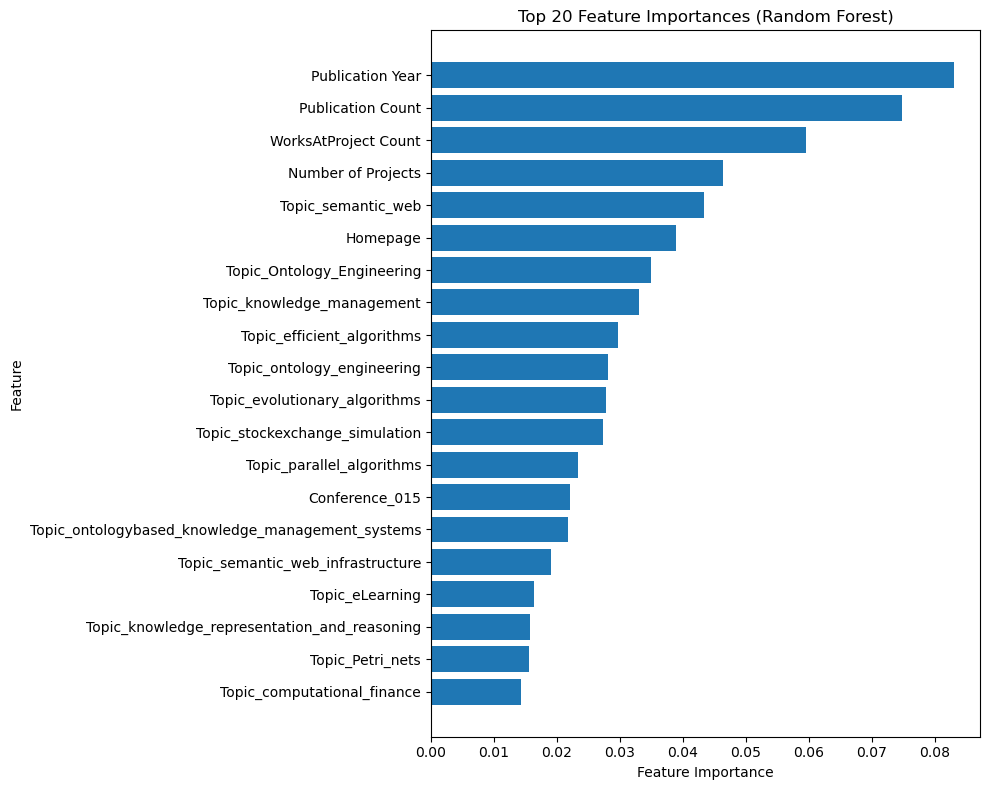

In [11]:
# ============================================================
# Plot Top 20 Feature Importances
# ============================================================

top_n = 20

top_features = feature_importance.head(top_n)

plt.figure(figsize=(10,8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title("Top 20 Feature Importances (Random Forest)")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "top_20_feature_importance.png",dpi=300)

plt.show()

In [12]:
# ============================================================
# Store Top Features
# ============================================================

top_feature_names = top_features["Feature"].tolist()

print("Top 20 Features\n")

for feature in top_feature_names:
    print(feature)

Top 20 Features

Publication Year
Publication Count
WorksAtProject Count
Number of Projects
Topic_semantic_web
Homepage
Topic_Ontology_Engineering
Topic_knowledge_management
Topic_efficient_algorithms
Topic_ontology_engineering
Topic_evolutionary_algorithms
Topic_stockexchange_simulation
Topic_parallel_algorithms
Conference_015
Topic_ontologybased_knowledge_management_systems
Topic_semantic_web_infrastructure
Topic_eLearning
Topic_knowledge_representation_and_reasoning
Topic_Petri_nets
Topic_computational_finance


In [13]:
# ============================================================
# Categorize Top Features
# ============================================================

for feature in top_feature_names:

    if feature.startswith("Topic_"):
        feature_type = "Research Topic"

    elif feature.startswith("Conference_"):
        feature_type = "Conference"

    else:
        feature_type = "Numeric Feature"

    print(f"{feature:<40} --> {feature_type}")

Publication Year                         --> Numeric Feature
Publication Count                        --> Numeric Feature
WorksAtProject Count                     --> Numeric Feature
Number of Projects                       --> Numeric Feature
Topic_semantic_web                       --> Research Topic
Homepage                                 --> Numeric Feature
Topic_Ontology_Engineering               --> Research Topic
Topic_knowledge_management               --> Research Topic
Topic_efficient_algorithms               --> Research Topic
Topic_ontology_engineering               --> Research Topic
Topic_evolutionary_algorithms            --> Research Topic
Topic_stockexchange_simulation           --> Research Topic
Topic_parallel_algorithms                --> Research Topic
Conference_015                           --> Conference
Topic_ontologybased_knowledge_management_systems --> Research Topic
Topic_semantic_web_infrastructure        --> Research Topic
Topic_eLearning                

## Permutation Feature Importance

In [14]:
# ============================================================
# Permutation Feature Importance
# ============================================================

pi = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

In [15]:
# ============================================================
# Create Permutation Importance Table
# ============================================================

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": pi.importances_mean,
    "Std": pi.importances_std
})

permutation_df = (
    permutation_df
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

permutation_df.head(20)

,Feature,Importance,Std
0,Publication Count,0.072222,0.043979
1,WorksAtProject Count,0.071296,0.043440
2,Publication Year,0.042593,0.030203
3,Topic_evolutionary_algorithms,0.031481,0.009443
4,Topic_efficient_algorithms,0.030556,0.013127
5,Topic_multimedia_systems,0.006481,0.011749
6,Topic_Petri_nets,0.004630,0.010352
7,Topic_Ontology_Engineering,0.004630,0.010352
8,Topic_database_systems,0.002778,0.008333
9,Topic_Computer_Science,0.000000,0.000000


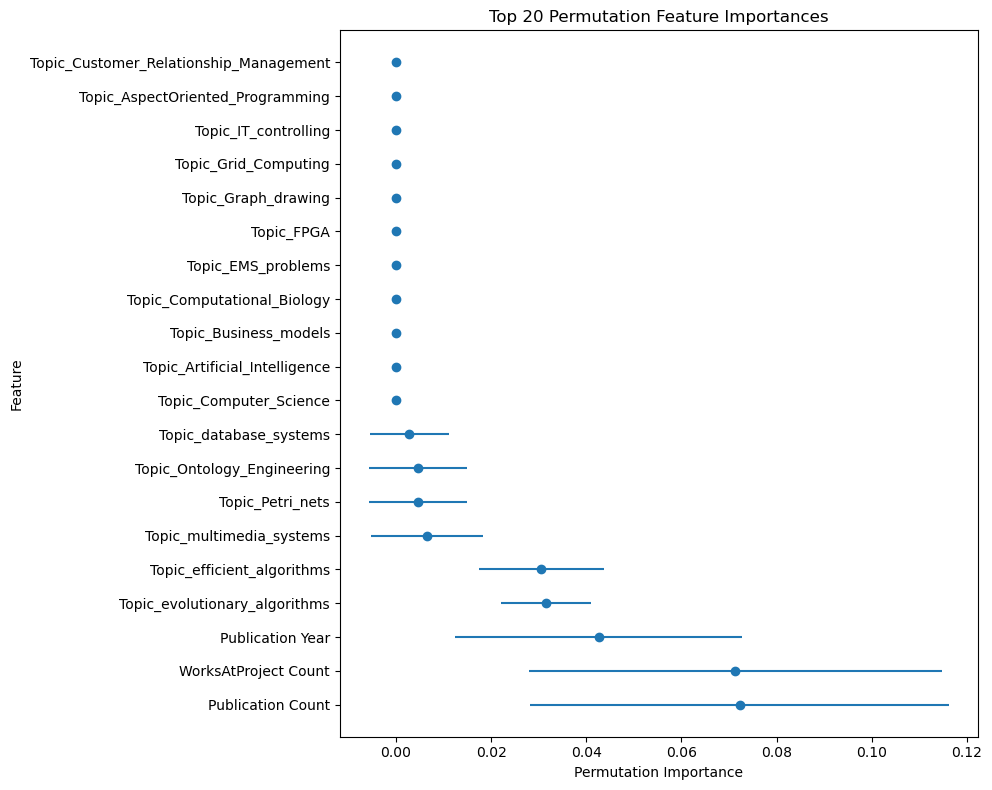

In [16]:
# ============================================================
# Plot Top 20 Permutation Importances
# ============================================================

top_n = 20

top_perm = permutation_df.head(top_n)

plt.figure(figsize=(10,8))

plt.errorbar(
    x=top_perm["Importance"],
    y=top_perm["Feature"],
    xerr=top_perm["Std"],
    marker="o",
    linestyle="none"
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")

plt.title("Top 20 Permutation Feature Importances")

plt.tight_layout()

plt.savefig(FIGURES_DIR / "permutation_feature_importance.png",dpi=300)

plt.show()

In [17]:
# ============================================================
# Store Top 5 Features
# ============================================================

top5_features = permutation_df.head(5)["Feature"].tolist()

print("Top 5 Features")

for feature in top5_features:
    print(feature)

Top 5 Features
Publication Count
WorksAtProject Count
Publication Year
Topic_evolutionary_algorithms
Topic_efficient_algorithms


In [18]:
# ============================================================
# Compare Feature Importance Methods
# ============================================================

comparison_df = feature_importance.merge(
    permutation_df,
    on="Feature",
    suffixes=("_RF", "_Permutation")
)

comparison_df = comparison_df.sort_values(
    by="Importance_Permutation",
    ascending=False
)

comparison_df.head(20)

,Feature,Importance_RF,Importance_Permutation,Std
1,Publication Count,0.074866,0.072222,0.043979
2,WorksAtProject Count,0.059599,0.071296,0.043440
0,Publication Year,0.083036,0.042593,0.030203
10,Topic_evolutionary_algorithms,0.027840,0.031481,0.009443
8,Topic_efficient_algorithms,0.029793,0.030556,0.013127
30,Topic_multimedia_systems,0.007780,0.006481,0.011749
6,Topic_Ontology_Engineering,0.035003,0.004630,0.010352
18,Topic_Petri_nets,0.015652,0.004630,0.010352
42,Topic_database_systems,0.004874,0.002778,0.008333
7,Topic_knowledge_management,0.033123,0.000000,0.000000


## Partial Dependence Plots (PDP)

In [19]:
group_names = {
    0: "Research Group 1",
    1: "Research Group 2",
    2: "Research Group 3",
    3: "Research Group 4"
}

Forschungsgruppen(id1instance)


C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: Fu

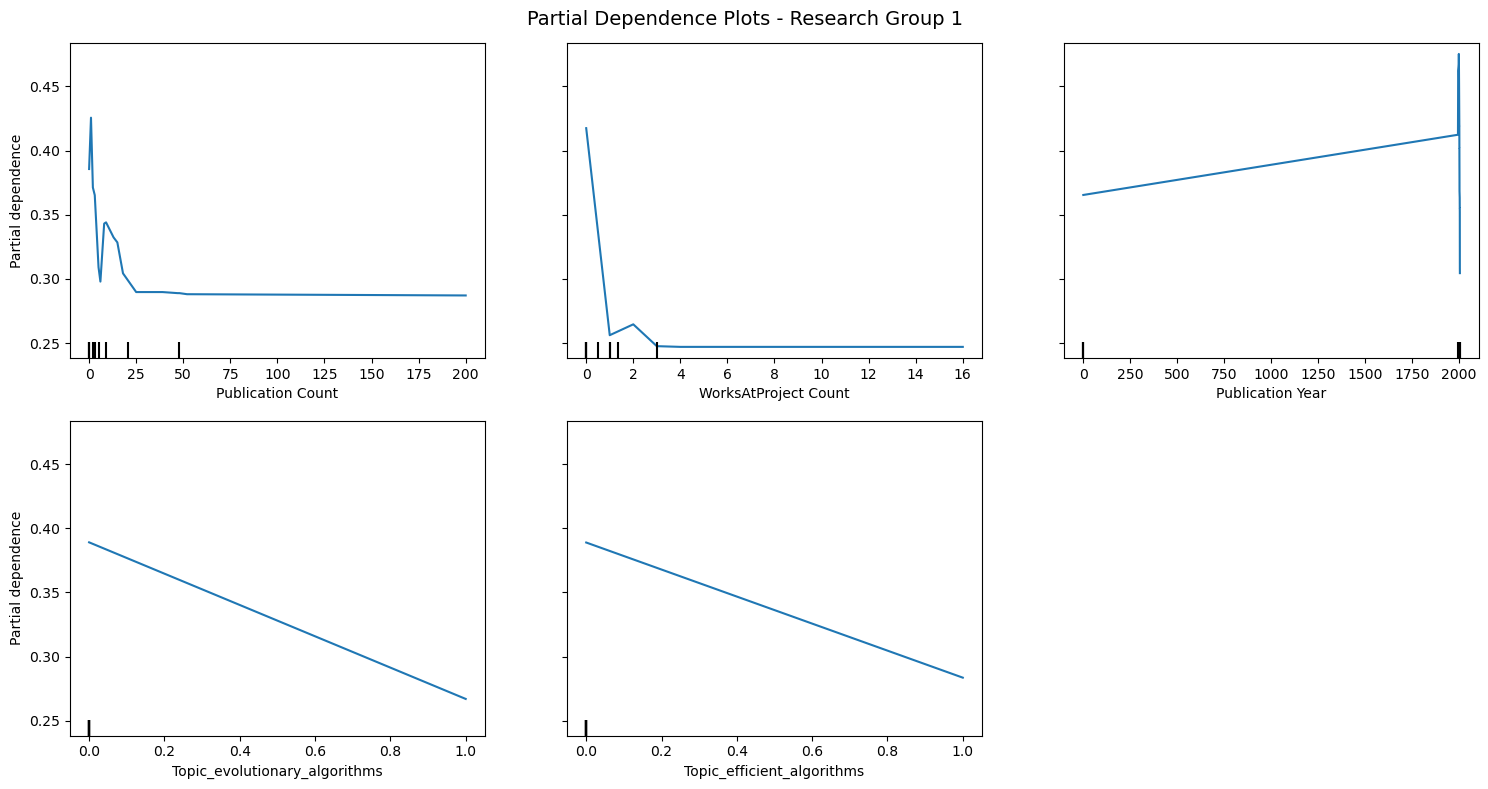

Forschungsgruppen(id2instance)


C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: Fu

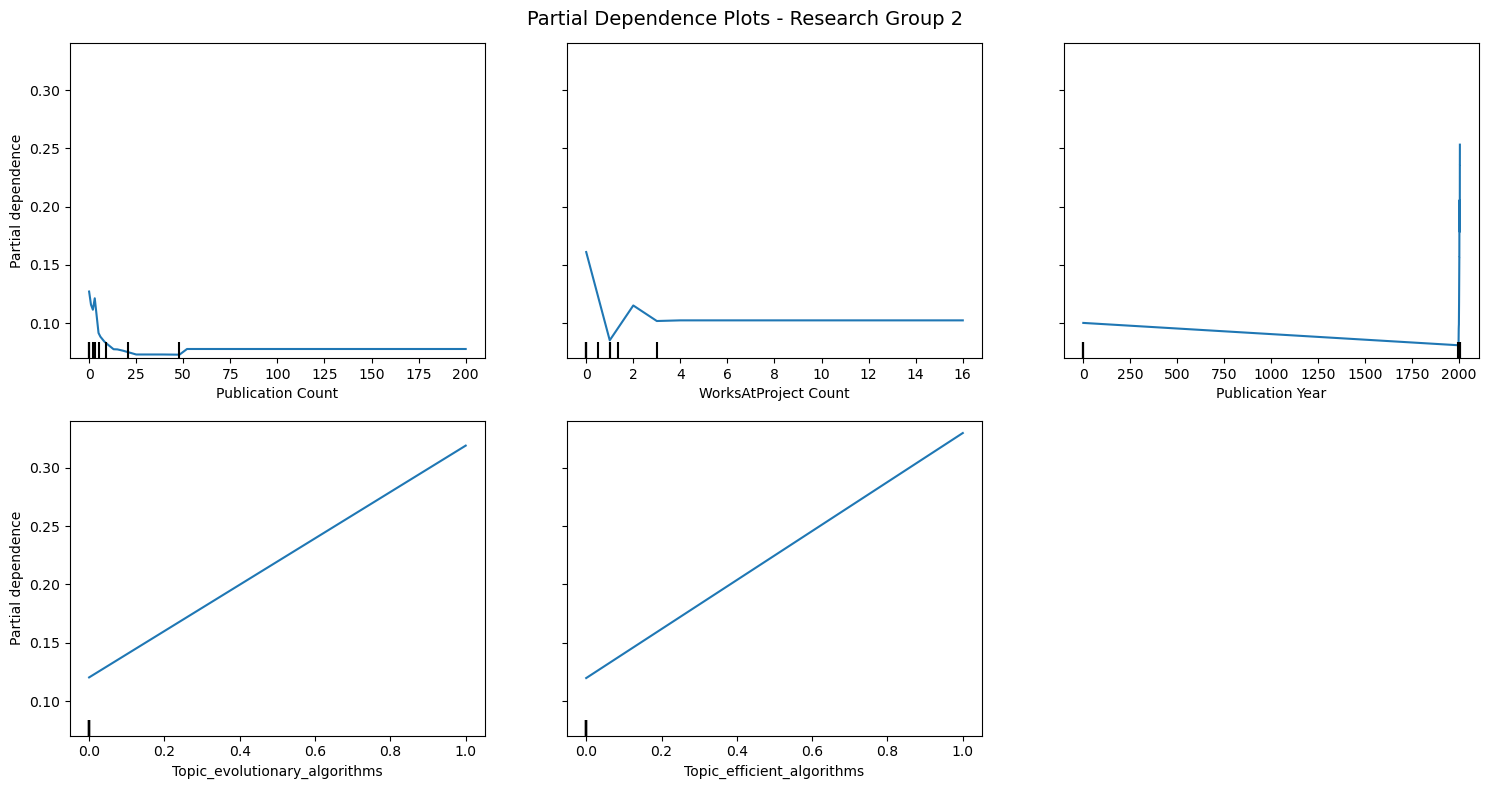

Forschungsgruppen(id3instance)


C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: Fu

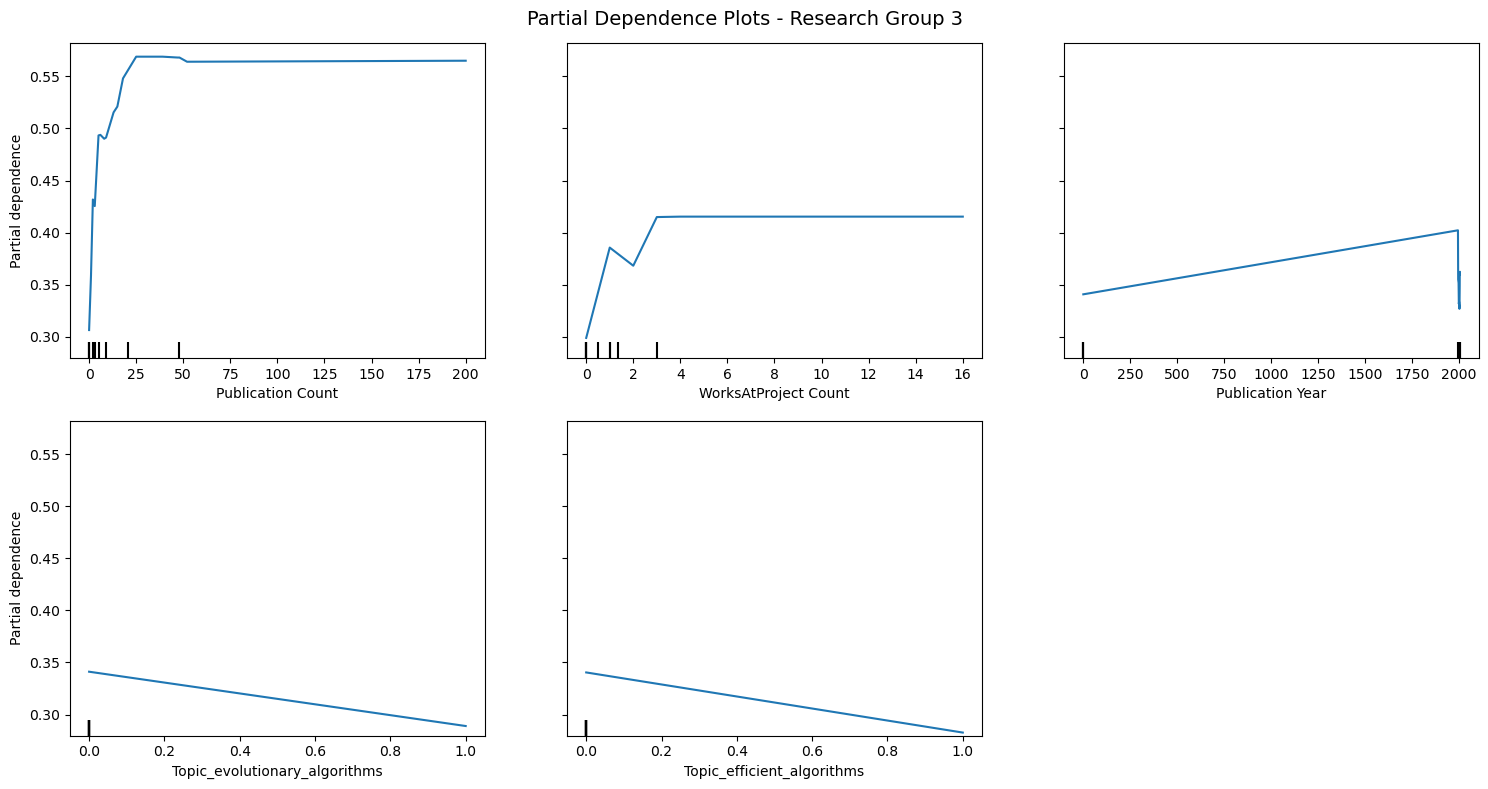

Forschungsgruppen(id4instance)


C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: Fu

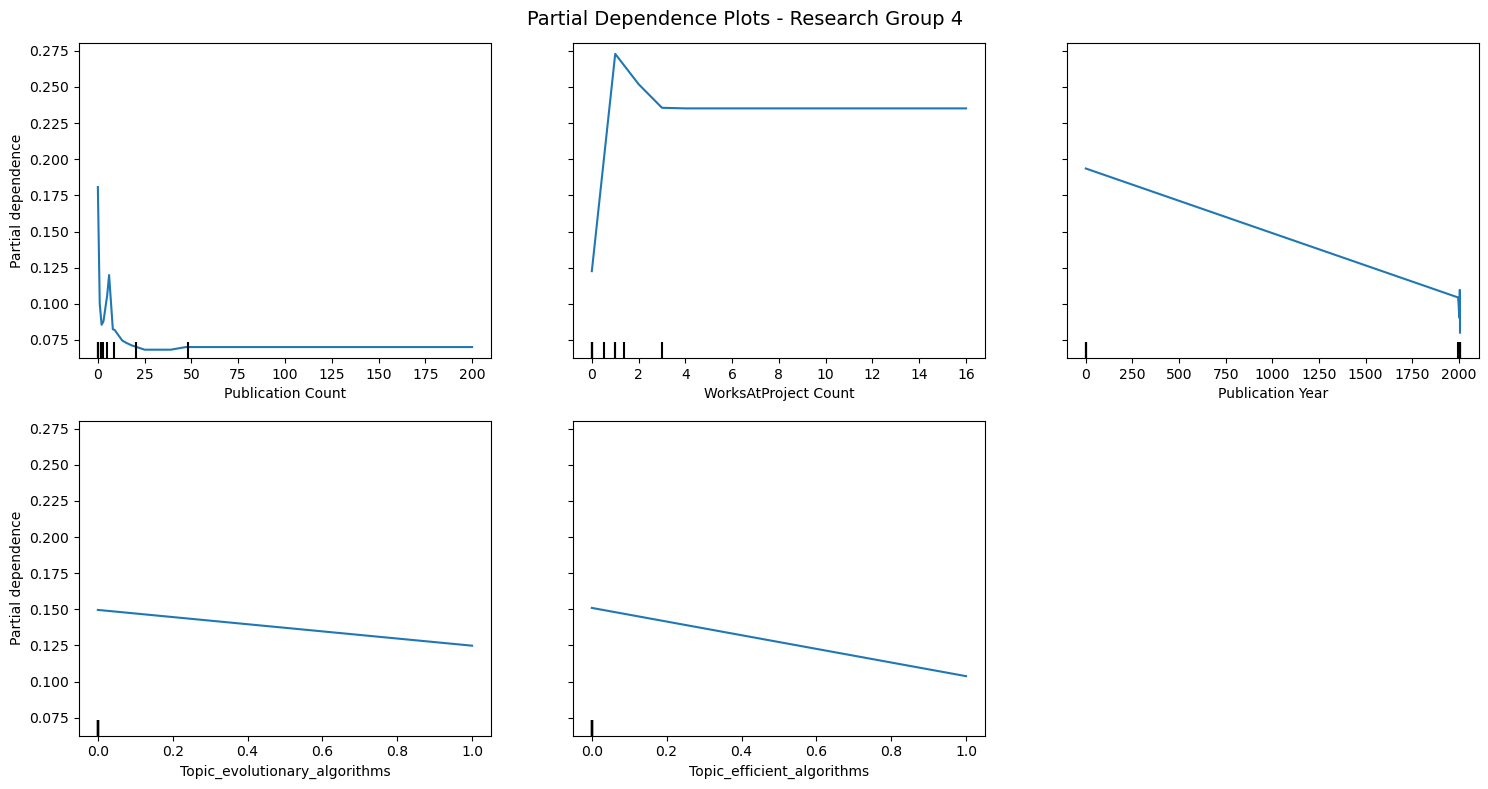

In [20]:
for class_index, class_name in enumerate(label_encoder.classes_):

    print("=" * 70)
    print(class_name)
    print("=" * 70)

    display = PartialDependenceDisplay.from_estimator(
        model,
        X_test,
        features=top5_features,
        target=class_index,
        feature_names=X_test.columns,
        n_cols=3
    )

    display.figure_.set_size_inches(15, 8)

    plt.suptitle(
        f"Partial Dependence Plots - {group_names[class_index]}",
        fontsize=14
        )

    plt.tight_layout()

    # Save figure
    display.figure_.savefig(
        FIGURES_DIR / f"pdp_new_{group_names[class_index].replace(' ', '_').lower()}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# 3) GLOBAL + LOCAL EXPLANATIONS

## ICE Plots

C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\manoj\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: Fu

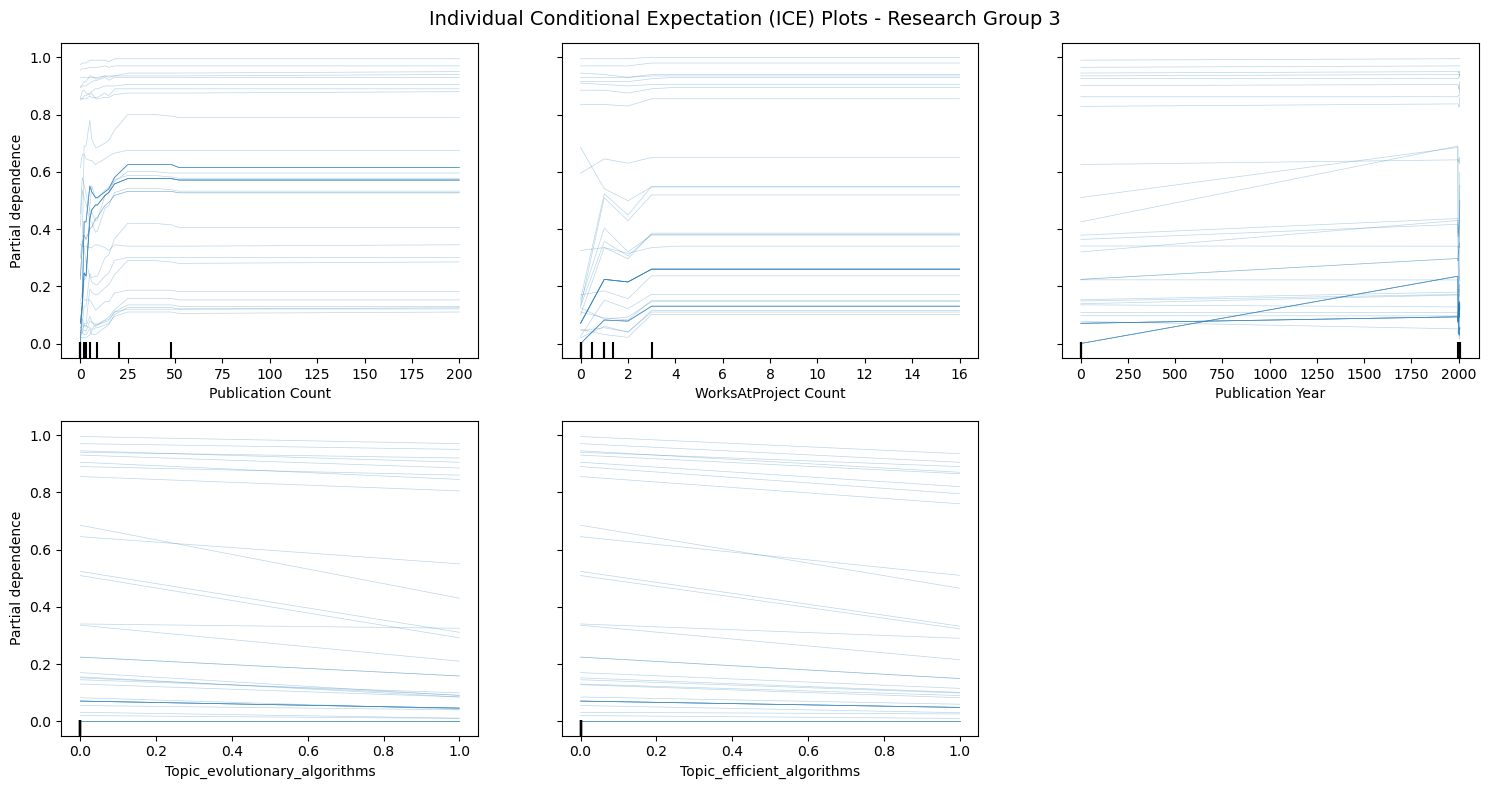

In [21]:
# ============================================================
# Individual Conditional Expectation (ICE) Plots
# ============================================================

display = PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=top5_features,
    target=2,                  # Research Group 3 (recommended)
    feature_names=X_test.columns,
    kind="individual",
    n_cols=3
)

display.figure_.set_size_inches(15, 8)

plt.suptitle(
    "Individual Conditional Expectation (ICE) Plots - Research Group 3",
    fontsize=14
)

plt.tight_layout()

plt.savefig(FIGURES_DIR / "ice_new_research_group_3_plot.png", dpi=300)

plt.show()

# 4) SHAP EXPLANATIONS

In [22]:
# ============================================================
# Create SHAP Explainer
# ============================================================

explainer = shap.TreeExplainer(model)

print("SHAP TreeExplainer created successfully!")

SHAP TreeExplainer created successfully!


In [23]:
# ============================================================
# Compute SHAP Values
# ============================================================

shap_values = explainer.shap_values(X_test)

print("SHAP values computed successfully!")

SHAP values computed successfully!


In [24]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [25]:
print(np.array(shap_values).shape)

(36, 181, 4)


In [26]:
print(shap_values.shape)

(36, 181, 4)


class_index = 2

because

- it has many samples,
- the PDP looks more informative on that

In [27]:
# ============================================================
# Create SHAP Explanation Object
# ============================================================

class_index = 2

shap_explanation = shap.Explanation(
    values=shap_values[:, :, class_index],
    base_values=np.repeat(
        explainer.expected_value[class_index],
        X_test.shape[0]
    ),
    data=X_test.values,
    feature_names=X_test.columns.tolist()
)

print("SHAP Explanation created successfully!")

SHAP Explanation created successfully!


## SHAP Global Feature Importance

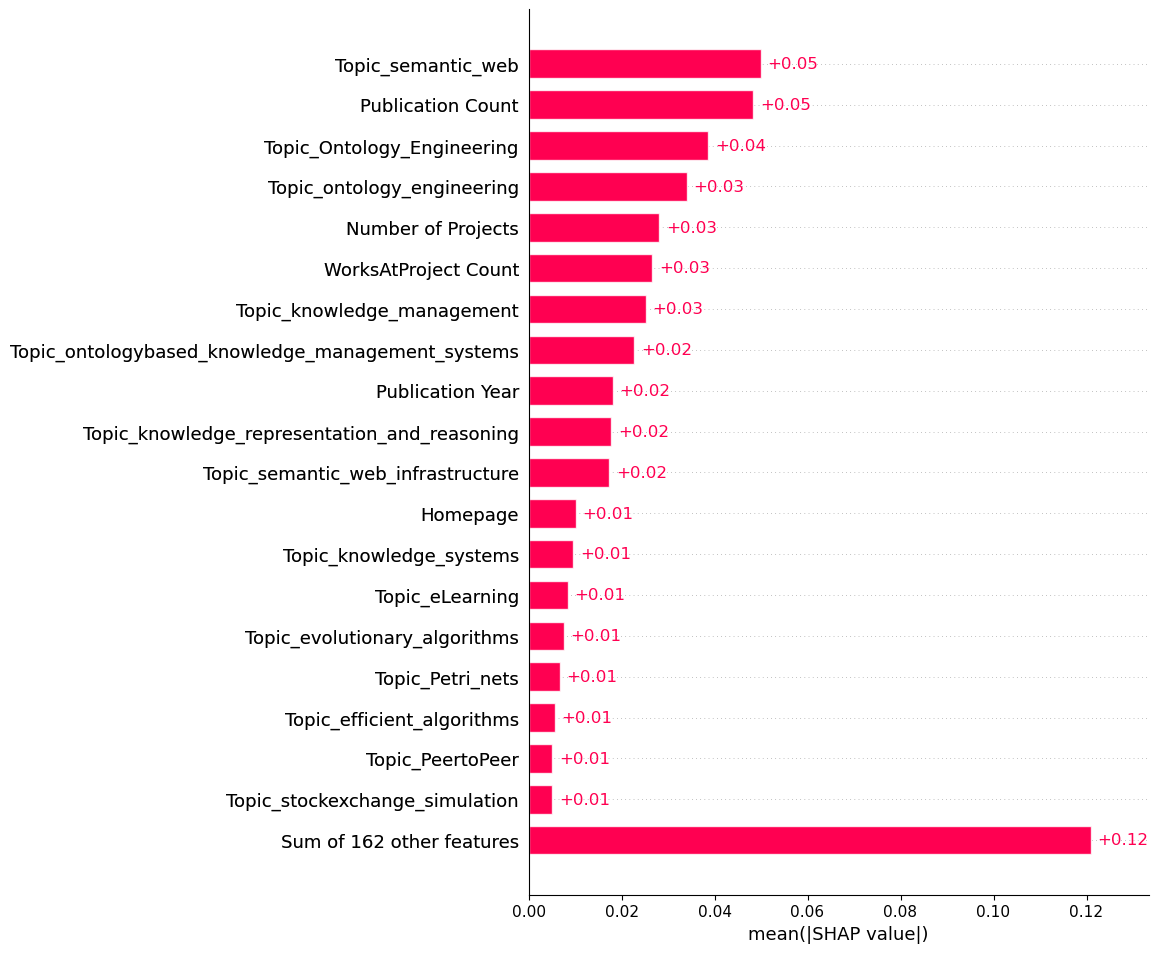

In [28]:
# ============================================================
# SHAP Global Feature Importance
# ============================================================

shap.plots.bar(
    shap_explanation,
    max_display=20
)

In [29]:
shap.plots.bar(
    shap_explanation,
    show=False
)

fig = plt.gcf()

fig.savefig(
    FIGURES_DIR / "shap_global_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

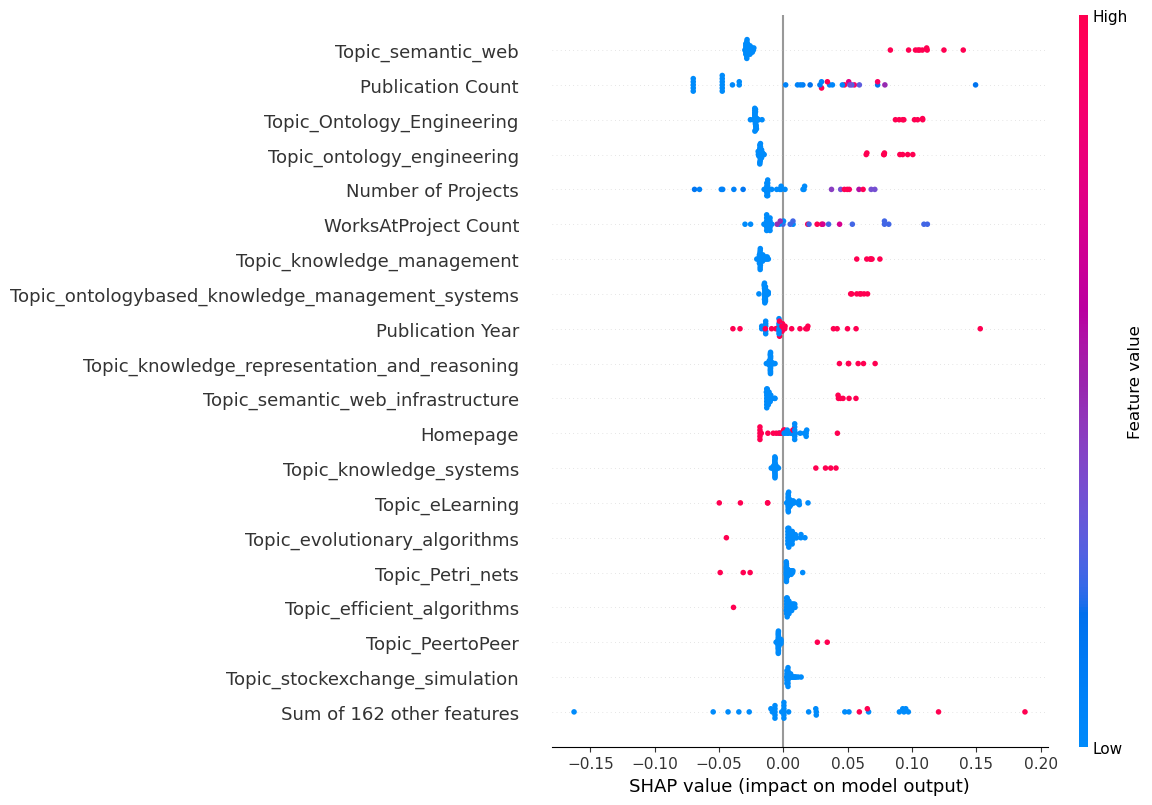

In [30]:
# ============================================================
# SHAP Beeswarm Plot
# ============================================================

shap.plots.beeswarm(
    shap_explanation,
    max_display=20
)

In [31]:
shap.plots.beeswarm(
    shap_explanation,
    show=False
)

fig = plt.gcf()

fig.savefig(
    FIGURES_DIR / "shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)

## SHAP explanantion on One Correct Prediction

In [32]:
# ============================================================
# Find Correct Predictions
# ============================================================

y_pred = model.predict(X_test)

correct_indices = np.where(y_pred == y_test)[0]

print(f"Correct Predictions: {len(correct_indices)}")
print(correct_indices)

Correct Predictions: 26
[ 0  1  2  3  4  5  6  7  9 10 11 13 14 15 16 19 20 21 22 23 26 27 28 30
 31 33]


In [33]:
sample_index = correct_indices[0]

In [34]:
print(feature_df.loc[test_mask].iloc[sample_index]["Person"])

Personen(id1855instance)


In [35]:
actual = label_encoder.inverse_transform([y_test[sample_index]])[0]
predicted = label_encoder.inverse_transform([y_pred[sample_index]])[0]

print(actual)
print(predicted)

Forschungsgruppen(id1instance)
Forschungsgruppen(id1instance)


In [36]:
# ============================================================
# Find the Most Confident Correct Prediction
# ============================================================

# Prediction probabilities
y_prob = model.predict_proba(X_test)

# Confidence of the predicted class
confidence = np.max(y_prob, axis=1)

# Confidence only for correct predictions
correct_confidence = confidence[correct_indices]

# Index of the most confident correct prediction
best_correct = correct_indices[np.argmax(correct_confidence)]

print("Selected Test Index :", best_correct)
print("Confidence          :", confidence[best_correct])

Selected Test Index : 27
Confidence          : 0.995


In [37]:
# ============================================================
# Information about the Selected Person
# ============================================================

selected_person = feature_df.loc[test_mask].iloc[best_correct]["Person"]

actual_group = label_encoder.inverse_transform(
    [y_test[best_correct]]
)[0]

predicted_group = label_encoder.inverse_transform(
    [y_pred[best_correct]]
)[0]

print("=" * 60)
print("Selected Person")
print("=" * 60)

print("Person            :", selected_person)
print("Actual Group      :", actual_group)
print("Predicted Group   :", predicted_group)
print("Prediction Confidence :", confidence[best_correct])

Selected Person
Person            : Personen(id13instance)
Actual Group      : Forschungsgruppen(id3instance)
Predicted Group   : Forschungsgruppen(id3instance)
Prediction Confidence : 0.995


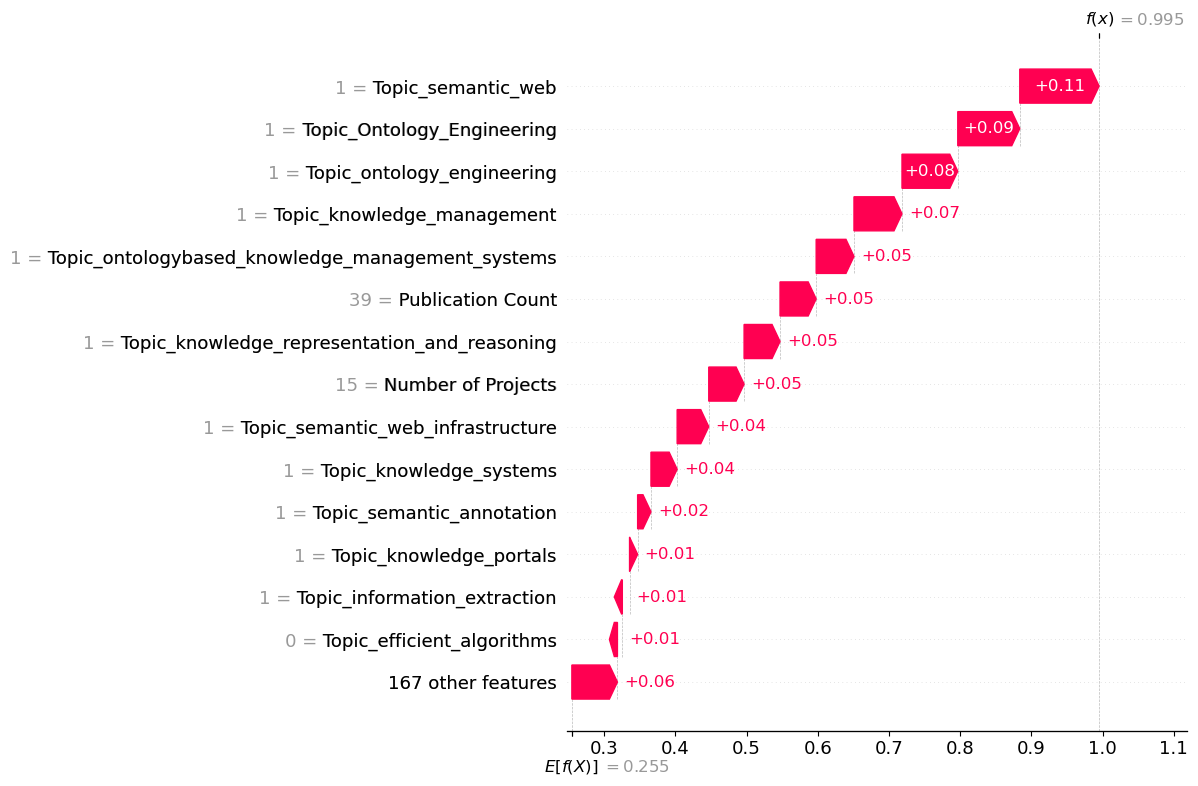

In [38]:
# ============================================================
# SHAP Waterfall Plot
# ============================================================

shap.plots.waterfall(
    shap_explanation[best_correct],
    max_display=15
)

In [39]:
plt.figure(figsize=(8, 6))

shap.plots.waterfall(
    shap_explanation[best_correct],
    max_display=15,
    show=False
)

plt.savefig(
    FIGURES_DIR / "shap_waterfall_best.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [40]:
# ============================================================
# Top SHAP Contributions
# ============================================================

sample_shap = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Value": shap_explanation.values[best_correct],
    "Feature Value": X_test.iloc[best_correct].values
})

sample_shap["Absolute SHAP"] = sample_shap["SHAP Value"].abs()

sample_shap = (
    sample_shap
    .sort_values("Absolute SHAP", ascending=False)
    .reset_index(drop=True)
)

sample_shap.head(15)

,Feature,SHAP Value,Feature Value,Absolute SHAP
0,Topic_semantic_web,0.111351,1.0,0.111351
1,Topic_Ontology_Engineering,0.087054,1.0,0.087054
2,Topic_ontology_engineering,0.078321,1.0,0.078321
3,Topic_knowledge_management,0.067418,1.0,0.067418
4,Topic_ontologybased_knowledge_management_systems,0.053084,1.0,0.053084
5,Publication Count,0.050740,39.0,0.050740
6,Topic_knowledge_representation_and_reasoning,0.050470,1.0,0.050470
7,Number of Projects,0.049611,15.0,0.049611
8,Topic_semantic_web_infrastructure,0.044368,1.0,0.044368
9,Topic_knowledge_systems,0.036761,1.0,0.036761


## SHAP explanantion on One Wrong Prediction

In [41]:
# ============================================================
# Find Incorrect Predictions
# ============================================================

incorrect_indices = np.where(y_pred != y_test)[0]

print(f"Incorrect Predictions: {len(incorrect_indices)}")
print(incorrect_indices)

Incorrect Predictions: 10
[ 8 12 17 18 24 25 29 32 34 35]


In [42]:
# ============================================================
# Most Confident Incorrect Prediction
# ============================================================

incorrect_confidence = confidence[incorrect_indices]

worst_index = incorrect_indices[np.argmax(incorrect_confidence)]

print("Selected Test Index :", worst_index)
print("Confidence          :", confidence[worst_index])

Selected Test Index : 24
Confidence          : 0.7785349983730461


In [43]:
selected_person = feature_df.loc[test_mask].iloc[worst_index]["Person"]

actual_group = label_encoder.inverse_transform(
    [y_test[worst_index]]
)[0]

predicted_group = label_encoder.inverse_transform(
    [y_pred[worst_index]]
)[0]

print("=" * 60)
print("Selected Person")
print("=" * 60)

print("Person            :", selected_person)
print("Actual Group      :", actual_group)
print("Predicted Group   :", predicted_group)
print("Prediction Confidence :", confidence[worst_index])

Selected Person
Person            : Personen(id81instance)
Actual Group      : Forschungsgruppen(id2instance)
Predicted Group   : Forschungsgruppen(id1instance)
Prediction Confidence : 0.7785349983730461


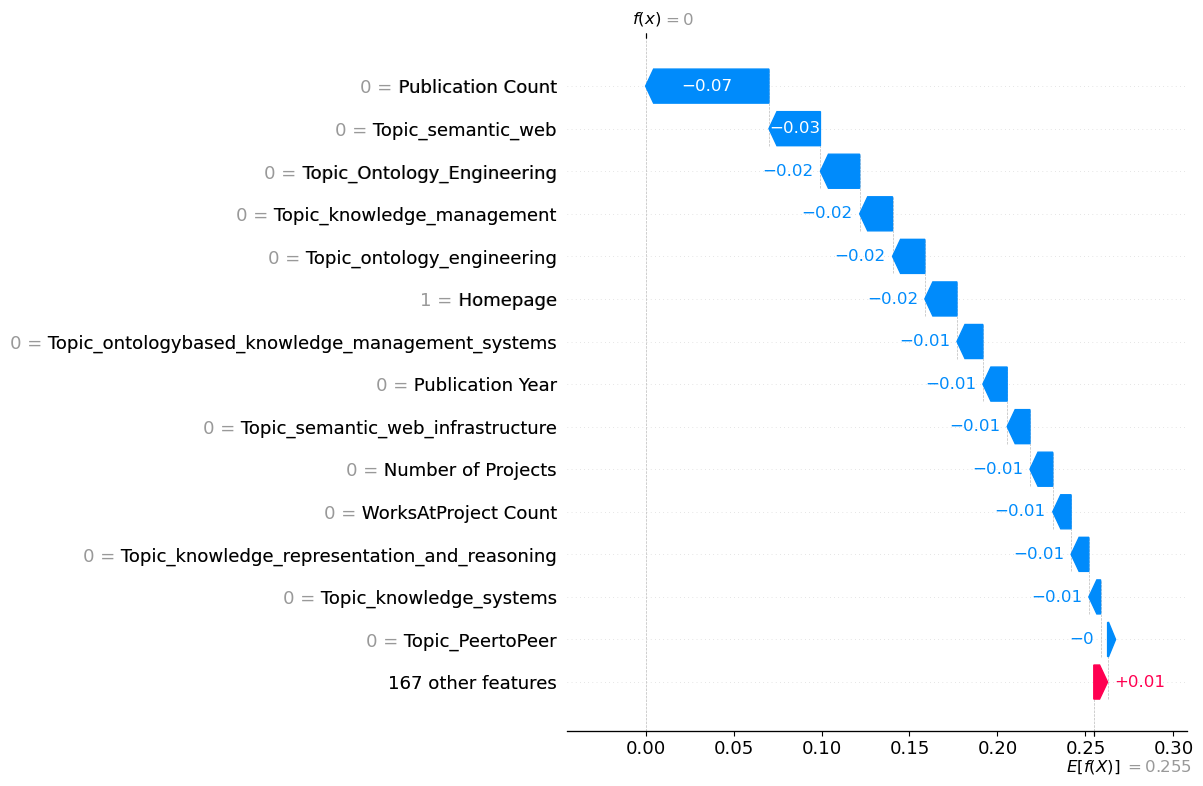

In [44]:
shap.plots.waterfall(
    shap_explanation[worst_index],
    max_display=15
)

In [45]:
plt.figure(figsize=(8, 6))

shap.plots.waterfall(
    shap_explanation[worst_index],
    max_display=15,
    show=False
)

plt.savefig(
    FIGURES_DIR / "shap_waterfall_worst.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [46]:
# ============================================================
# Top SHAP Contributions
# ============================================================

sample_shap = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Value": shap_explanation.values[worst_index],
    "Feature Value": X_test.iloc[best_correct].values
})

sample_shap["Absolute SHAP"] = sample_shap["SHAP Value"].abs()

sample_shap = (
    sample_shap
    .sort_values("Absolute SHAP", ascending=False)
    .reset_index(drop=True)
)

sample_shap.head(15)

,Feature,SHAP Value,Feature Value,Absolute SHAP
0,Publication Count,-0.070111,39.00,0.070111
1,Topic_semantic_web,-0.029264,1.00,0.029264
2,Topic_Ontology_Engineering,-0.022303,1.00,0.022303
3,Topic_knowledge_management,-0.018677,1.00,0.018677
4,Topic_ontology_engineering,-0.018367,1.00,0.018367
5,Homepage,-0.018262,1.00,0.018262
6,Topic_ontologybased_knowledge_management_systems,-0.014728,1.00,0.014728
7,Publication Year,-0.013803,2003.05,0.013803
8,Topic_semantic_web_infrastructure,-0.012968,1.00,0.012968
9,Number of Projects,-0.012944,15.00,0.012944
